# Get started with Earth Engine for Python

This quickstart will give you an interactive introduction to visualizing and
analyzing geospatial data with the Earth Engine Python interface.

## Before you begin

[Register or create](https://code.earthengine.google.com/register) a Google Cloud Project; you'll be prompted to complete the following steps. If you already have a project registered for Earth Engine access, skip to the next section.

  * Select noncommercial.
  * Project type: 
  * Create a new Google Cloud project or select an existing project.
  * Confirm your project information.  




## Notebook setup

**1.** Import the Earth Engine and geemap libraries.

In [45]:
import ee
import geemap.core as geemap

**2.** Authenticate and initialize the Earth Engine service. Follow the
resulting prompts to complete authentication. Be sure to replace PROJECT_ID
with the name of the project you set up for this quickstart.

In [46]:
ee.Authenticate()
ee.Initialize(project='riftwaters')

3. Select a region of interest and time range

In [74]:
##Lake baringo

ROI = ee.Geometry.Polygon(
            [
                [35.98391292157122, 0.4153611370519164],
                [36.16518733563372, 0.4153611370519164],
                [36.16518733563372, 0.7446867187538047],
                [35.98391292157122, 0.7446867187538047],
            ]
        )

start_date = '2020-01-01'   ## ensure dates are in the format 'YYYY-MM-DD'
end_date = '2020-01-31'

4. Downloading Images from various catalogs

In [75]:
##Downloading sentinel-1 image collection
S1_image = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(ROI)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .select("VV")
)


count = S1_image.size().getInfo()
print(f"  Found {count} images")


# Apply preprocessing
def preprocess_sar(image):
    # Apply thermal noise removal, radiometric calibration, and terrain correction
    image = image.select("VV")
    image = image.focal_median(radius=10, units="meters")
    return image.clip(ROI)

processed = S1_image.map(preprocess_sar)

# Create median composite
composite = processed.median()

# Get list of images

        
m = geemap.Map()
m.set_center(36., 0.6, 12)
m.add_layer(composite, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
m

  Found 2 images


Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [76]:
def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image).clip(ROI)


img_vv = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(ROI)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select('VV')
    .map(mask_edge)
)

desc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).median()
asc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).median()




m = geemap.Map()
m.set_center(36., 0.6, 12)
#m.add_layer(asc, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
m.add_layer(desc, {'min': -25, 'max': 5}, 'Multi-T Mean DESC', True)
m

Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [ ]:
# Load Sentinel-2 image collection
def mask_s2_clouds(image):
    qa = image.select("QA60")
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask)

s2_image = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(ROI)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", 20))
)
count = s2_image.size().getInfo()
print(f"Found {count} Sentinel-2 images")




s2_image = s2_image.map(mask_s2_clouds)
s2_image = s2_image.median().clip(ROI)


visualization = {
    "min": 0.0,
    "max": 1000,
    "bands": ["B4", "B3", "B2"],
}

m = geemap.Map()
m.set_center(36., 0.6, 10)
m.add_layer(s2_image, visualization, "RGB")
m

Found 1 Sentinel-2 images


Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Saving an Image

(2340, 1766)
0 1


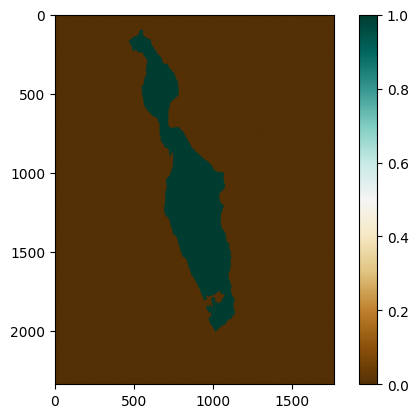

In [44]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("/home/desy/rift-waters/dataset/bogoria/processed/sar_water_mask/2020-01-31.tif") as src:
    image = src.read(1)
    
    print(image.shape)
    print(image.min(), image.max())
    plt.imshow(image, cmap='BrBG')
    plt.colorbar()
    plt.show()

## Add raster data to a map

**1.** Load climate data for a given period and display its metadata.

**2.** Instantiate a map object and add the temperature band as a layer with
specific visualization properties. Display the map.

## Add vector data to a map

**1.** Create a vector data object with points for three cities.

**2.** Add the city locations to the map and redisplay it.

## Extract and chart data

**1.** Import the Altair charting library.

**2.** Extract the climate data for the three cities as a pandas DataFrame.

**3.** Plot the temperature for the cities as a bar chart.

## What's next

  * Learn about analyzing data with Earth Engine's [objects and methods](https://developers.google.com/earth-engine/guides/objects_methods_overview).
  * Learn about Earth Engine's [processing environments](https://developers.google.com/earth-engine/guides/processing_environments).
  * Learn about Earth Engine's [machine learning capabilities](https://developers.google.com/earth-engine/guides/machine-learning).
  * Learn how to [export your computation results to BigQuery](https://developers.google.com/earth-engine/guides/exporting_to_bigquery).